# Pipeline: Reset & Populate

In [1]:
import logging, sys
from graph_utils import NeatFormatter

handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(NeatFormatter())
logging.root.handlers = []
logging.root.addHandler(handler)
logging.root.setLevel(logging.INFO)

from populate import populate_all
from enrich import enrich_all
from reasoning import check_consistency
from graph_embedding import (
    load_object_property_triples,
    train_embedding_model,
    save_embedding_model,
    load_embedding_model,
    visualize_embeddings,
    build_entity_type_map,
    build_subclass_ancestors,
    filter_predictions_by_class,
    TOP_K_PREDICTIONS,
)
from config import ONT
from graph_utils import local_name, reset_data_file, save_graph
from pykeen.predict import predict_target
from visualize import main as run_visualize


/Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
graph = reset_data_file()
populate_all(graph)


▸ Province
  · East_Nusa_Tenggara
  · West_Nusa_Tenggara
  · Bali

▸ Island
  · Nusa_Penida  (locatedIn: Bali)
  · Nusa_Lembongan  (locatedIn: Bali)
  · Serangan_Island  (locatedIn: Bali)
  · Menjangan_Island  (locatedIn: Bali)
  · Nusa_Ceningan  (locatedIn: Bali)
  ↳ Bali: 5 islands
  · Moyo_Island  (locatedIn: West_Nusa_Tenggara)
  · Lombok  (locatedIn: West_Nusa_Tenggara)
  · Satonda_Island  (locatedIn: West_Nusa_Tenggara)
  · Bungin_Island  (locatedIn: West_Nusa_Tenggara)
  ↳ NTB: 4 islands
  · Flores  (locatedIn: East_Nusa_Tenggara)
  · Komodo_island  (locatedIn: East_Nusa_Tenggara)
  · Rote_Island  (locatedIn: East_Nusa_Tenggara)
  · Pamana_Island  (locatedIn: East_Nusa_Tenggara)
  · Besar_Island_Flores  (locatedIn: East_Nusa_Tenggara)
  · Dambila  (locatedIn: East_Nusa_Tenggara)
  · Pantar  (locatedIn: East_Nusa_Tenggara)
  · Palu_e  (locatedIn: East_Nusa_Tenggara)
  · Ndao_Island  (locatedIn: East_Nusa_Tenggara)
  · Dana_Island_Sabu_Raijua  (locatedIn: East_Nusa_Tenggara)
  · 

# Enrich, Save, Reason

In [3]:
import os, sys

enrich_all(graph)
save_graph(graph)

# Suppress owlready2 stdout (java command line, HermiT timing, cyclic-type warnings)
with open(os.devnull, "w") as _devnull:
    _stdout, sys.stdout = sys.stdout, _devnull
    result = check_consistency()
    sys.stdout = _stdout

print("Ontology is", "CONSISTENT ✓" if result else "INCONSISTENT ✗")



▸ Country Backbone
  ↳ 3 provinces linked to Indonesia

▸ Bali Island Fix
  · Bali_Island (DBpedia types Bali as Province, not Island)

▸ Island → Province Links
  ↳ 23 links (DBpedia isPartOf + wikiLink)

▸ Location Links
  ↳ 204 links (wikiPageWikiLink)

▸ Activity Individuals
  ↳ 8 created: Surfing, Snorkeling, Diving, Sailing, Kayaking, Hiking, Sightseeing, Cultural_Tour

▸ Activity Links
  ↳ 30 links (DBpedia categories + wikiLinks)

▸ Activity Fallbacks
  ↳ 44 links assigned to entities with no DBpedia coverage

▸ Tourist Attraction Hubs
  ↳ 49 hub edges (City → hasTouristAttraction)

▸ Accommodation Hubs
  ↳ 5 hub edges (City → hasAccommodation)

▸ Visitor Counts
  · Komodo_National_Park: 45,000 visitors
  · Kelimutu_National_Park: 12,507 visitors
  · Mount_Rinjani_National_Park: 117,715 visitors
  · West_Bali_National_Park: 5,592 visitors
  ↳ 4 values added

▸ Ratings
  ↳ 28 hasRating values added
  ✗ Hotel domain conflict: Amankila, Tandjung_Sari, Tjampuhan_Hotel, InterContin

* Owlready2 * Running HermiT...
    java -Xmx2000M -cp /Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/owlready2/hermit:/Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/owlready2/hermit/HermiT.jar org.semanticweb.HermiT.cli.CommandLine -c -O -D -I file:////var/folders/1j/z8zbdmfs73j3wgb3vtt985140000gn/T/tmp10fi6tur -Y


Ontology is CONSISTENT
── Individuals per populated class ──
  Province              ( 3) East_Nusa_Tenggara, West_Nusa_Tenggara, Bali
  Island                (30) Besar_Island__Flores, Flores, Lombok, Sumba, Sumbawa, Komodo_island …
  City                  (52) East_Nusa_Tenggara, West_Nusa_Tenggara, Bali, Central_Lombok_Regency, Central_Sumba_Regency, East_Flores_Regency …
  Beach                 (23) Pandawa_Beach, Legian, Padang_Padang_Beach, Dreamland_Beach, Lovina_Beach, Balangan_Beach …
  Park                  ( 6) West_Bali_National_Park, Mount_Rinjani_National_Park, Kelimutu_National_Park, Komodo_National_Park, Manupeu_Tanah_Daru_National_Park, Laiwangi_Wanggameti_National_Park
  Volcano               ( 4) Bratan_volcano, Mount_Agung, Mount_Batur, Mount_Tambora
  Museum                (11) Le_Mayeur_Museum, Semarajaya_Museum, Neka_Art_Museum, Bali_Museum, Museum_Pasifika, Museum_Rudana …
  Temple                (14) Pura_Taman_Ayun, Pura_Luhur_Batukaru, Pura_Penataran_Agung_Le

* Owlready2 * HermiT took 0.884192943572998 seconds
* Owlready * (NB: only changes on entities loaded in Python are shown, other changes are done but not listed)
* Owlready2 * Warning: ignoring cyclic type of, involving storid 589

* Owlready2 * Warning: ignoring cyclic type of, involving storid 597

* Owlready2 * Warning: ignoring cyclic type of, involving storid 607

* Owlready2 * Warning: ignoring cyclic type of, involving storid 609

* Owlready2 * Warning: ignoring cyclic type of, involving storid 611

* Owlready2 * Warning: ignoring cyclic type of, involving storid 594



# Graph Embedding

In [4]:
# Train embedding model

%matplotlib inline

emb_graph, base_triples = load_object_property_triples()
training_result, triples_factory = train_embedding_model(base_triples, 430)
save_embedding_model(training_result, triples_factory)
entity_type_map = build_entity_type_map(emb_graph)
ancestors_map = build_subclass_ancestors(emb_graph)

No cuda devices were available. The model runs on CPU
Using device: None
Inferred unique=False for Embedding()
Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


/Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu: 100%|██████████| 430/430 [00:48<00:00,  8.79epoch/s, loss=0.313, prev_loss=0.326]

When evaluating the test dataset, validation triples are added to the set of known positive triples which are filtered out when performing filtered evaluation following the approach described by (Bordes et al., 2013).
Using automatic batch size on device.type='cpu' can cause unexplained out-of-memory crashes. Therefore, we use a conservative small batch_size=32. Performance may be improved by explicitly specifying a larger batch size.



Evaluating on cpu:   0%|          | 0.00/1.71k [00:00<?, ?triple/s]

Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).


Evaluating on cpu: 100%|██████████| 1.71k/1.71k [00:00<00:00, 17.1ktriple/s]

Evaluation took 0.11s seconds
Stored TriplesFactory(num_entities=557, num_relations=22, create_inverse_triples=False, num_triples=1707) to file:///Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/embedding_model/triples
Saved embedding model → embedding_model/


In [2]:
# Load embedding from saved model

try:
    embed_model = training_result.model
except NameError:
    embed_model, triples_factory = load_embedding_model()
    emb_graph, _ = load_object_property_triples()
    entity_type_map = build_entity_type_map(emb_graph)
    ancestors_map = build_subclass_ancestors(emb_graph)
else:
    embed_model = training_result.model

Loading from file:///Users/f/Documents/EMLDS/2-Computational-Semantics/Projects/import_ver/embedding_model/triples
No random seed is specified. This may lead to non-reproducible results.
Inferred unique=False for Embedding()
Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
Loaded embedding model ← embedding_model/


Saved cluster plot → ./graph_vis/embedding_clusters.png


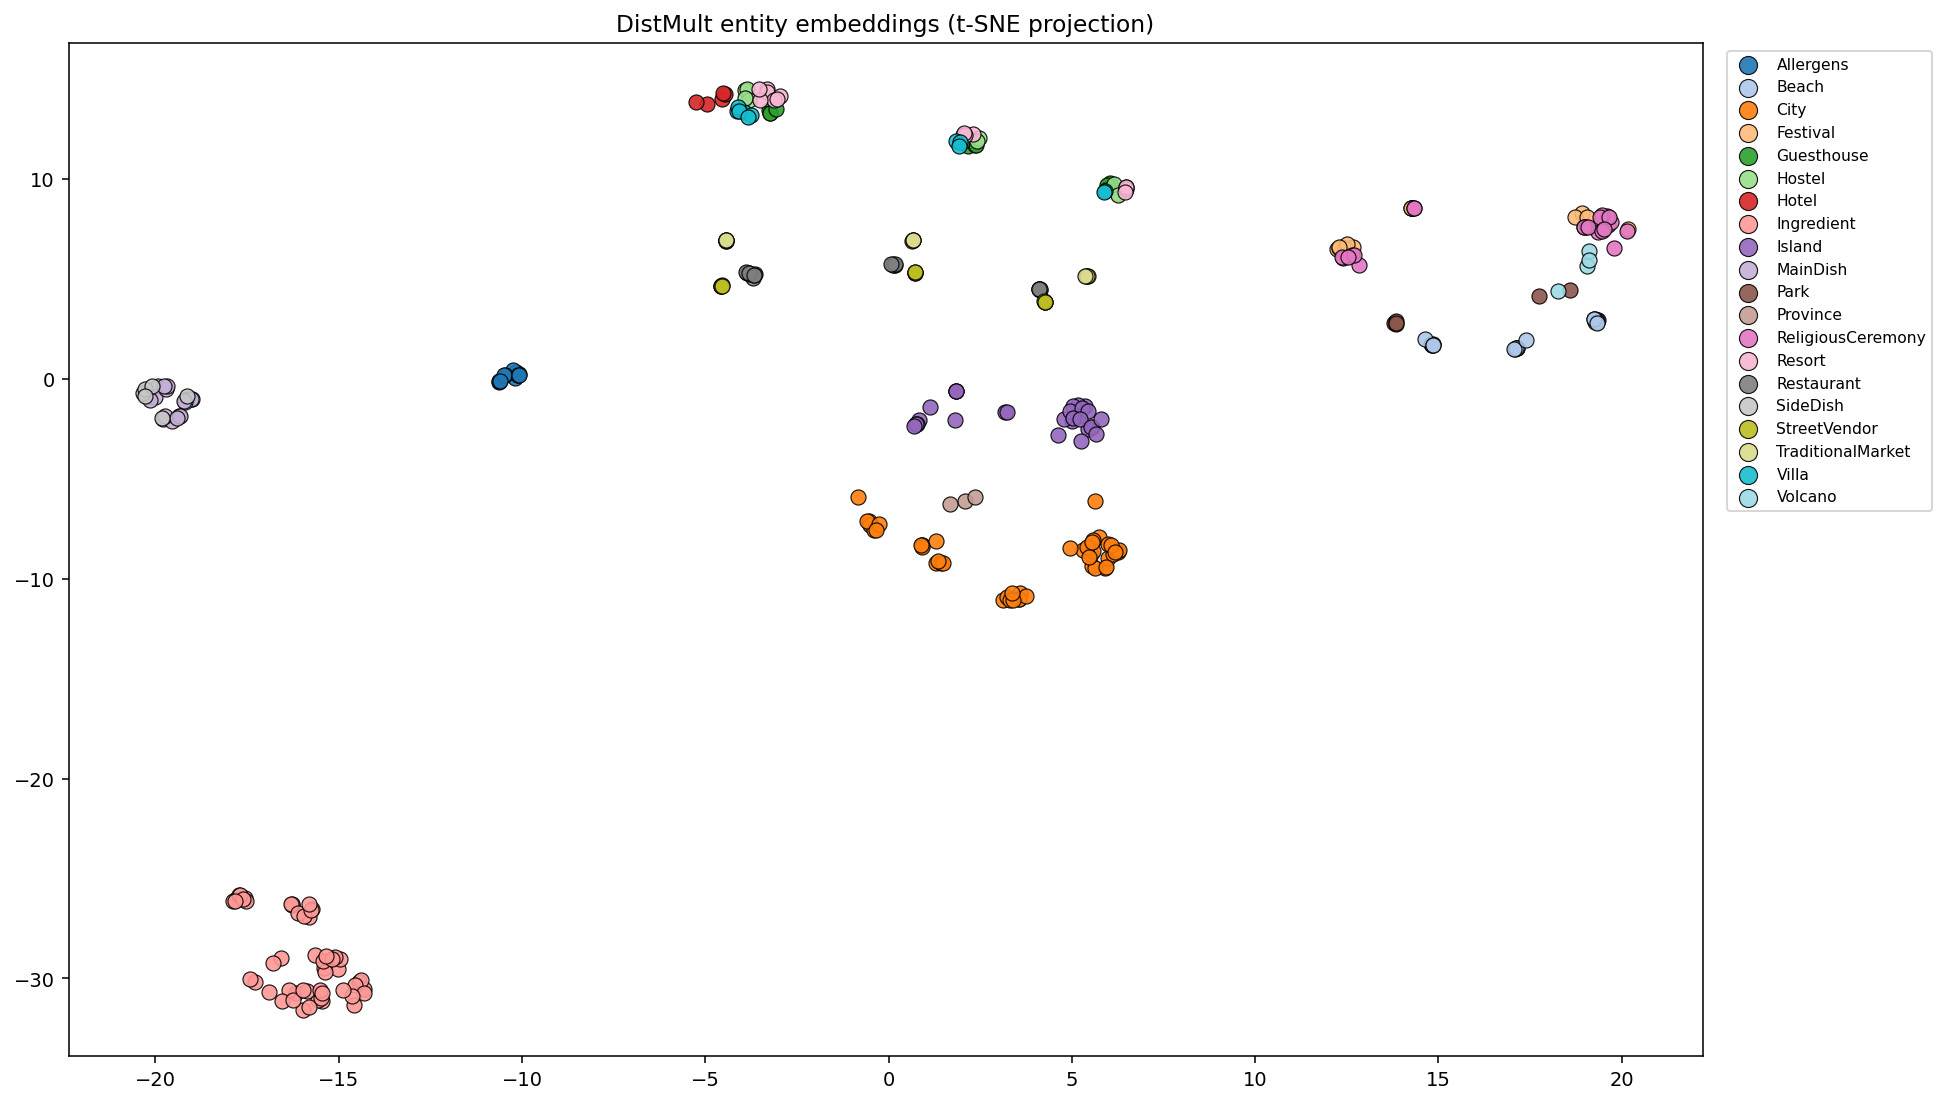

In [3]:
visualize_embeddings(embed_model, triples_factory, emb_graph)

from IPython.display import Image, display
display(Image(filename="graph_vis/embedding_clusters.png"))

# Link Prediction

Change `head`, `relation`, and `expected_class` below, then re-run the cell.

In [6]:
# ── Define as many queries as you like, then re-run this cell ──
# (head, relation, expected_class)
queries = [
    ("Satonda_Island",        "hasFood",                "TypicalFood"),
    ("Komodo_National_Park",  "hasActivity",            "Activities"),
    ("Lovina_Beach",          "hasActivity",            "Activities"),
    ("Pura_Taman_Ayun",       "hasActivity",            "Activities"),
    ("Denpasar",              "hasTouristAttraction",   "Park"),
    ("Kupang",                "hasTouristAttraction",   "TraditionalHouse"),
    ("Denpasar",              "hasFood",                "TypicalFood"),
    ("Ayam_Taliwang",         "originatesFrom",         "Province"),
    ("Lawar",                 "originatesFrom",         "City"),
    ("Pink_Beach",            "locatedIn",              "Park"),
    ("Lombok",                "locatedInProvince",      "Province"),
    ("Bima_Airport",          "locatedInCity",          "City"),
    ("Denpasar",              "hasAccommodation",       "Resort"),
]

for head, relation, expected_class in queries:
    head_iri     = str(ONT[head])
    relation_iri = str(ONT[relation])

    print(f"{head}  --{relation}-->  ?   [filtered to {expected_class}]")

    if head_iri not in triples_factory.entity_to_id:
        print(f"  '{head}' is not in the training data\n")
        continue
    if relation_iri not in triples_factory.relation_to_id:
        print(f"  '{relation}' is not a known relation\n")
        continue

    raw   = predict_target(
        model=embed_model, head=head_iri,
        relation=relation_iri, triples_factory=triples_factory,
    ).df
    valid = filter_predictions_by_class(raw, expected_class, entity_type_map, ancestors_map)

    if valid.empty:
        print(f"  no {expected_class} candidates found\n")
        continue

    print(f"  {'Score':>8}  Candidate")
    for _, row in valid.head(TOP_K_PREDICTIONS).iterrows():
        print(f"  {row['score']:8.4f}  {local_name(row['tail_label'])}")
    best = valid.iloc[0]
    print(f"  >> Best: {local_name(best['tail_label'])} ({best['score']:.4f})")
    print()


Satonda_Island  --hasFood-->  ?   [filtered to TypicalFood]
     Score  Candidate
    0.1406  Ares
    0.1359  Bebalung
    0.1353  Ayam_Taliwang
    0.1235  Nasi_Balap_Puyung
    0.1189  Sate_Rembiga
  >> Best: Ares (0.1406)

Komodo_National_Park  --hasActivity-->  ?   [filtered to Activities]
     Score  Candidate
    0.9125  Sightseeing
    0.8818  Hiking
    0.8643  Diving
    0.5890  Surfing
    0.5825  Snorkeling
  >> Best: Sightseeing (0.9125)

Lovina_Beach  --hasActivity-->  ?   [filtered to Activities]
     Score  Candidate
    0.9980  Sailing
    0.9963  Snorkeling
    0.9943  Surfing
    0.9910  Kayaking
    0.7317  Diving
  >> Best: Sailing (0.9980)

Pura_Taman_Ayun  --hasActivity-->  ?   [filtered to Activities]
     Score  Candidate
    0.9776  Cultural_Tour
    0.1851  Sightseeing
    0.1110  Surfing
    0.1074  Sailing
    0.1072  Snorkeling
  >> Best: Cultural_Tour (0.9776)

Denpasar  --hasTouristAttraction-->  ?   [filtered to Park]
     Score  Candidate
    0.9196  W

# Save Predictions / Merge to Graph (Optional)
Review the output above, then run this cell to write the best predictions to .

In [ ]:
from rdflib import URIRef

# Collect the best prediction for each valid query
to_save = []
for head, relation, expected_class in queries:
    head_iri     = str(ONT[head])
    relation_iri = str(ONT[relation])
    if head_iri not in triples_factory.entity_to_id: continue
    if relation_iri not in triples_factory.relation_to_id: continue
    raw   = predict_target(
        model=training_result.model, head=head_iri,
        relation=relation_iri, triples_factory=triples_factory,
    ).df
    valid = filter_predictions_by_class(raw, expected_class, entity_type_map)
    if not valid.empty:
        best_iri = valid.iloc[0]["tail_label"]
        to_save.append((head_iri, relation_iri, best_iri))

# Write to emb_graph and save data.owl
for s, p, o in to_save:
    emb_graph.add((URIRef(s), URIRef(p), URIRef(o)))
    print(f"  + {local_name(s)}  --{local_name(p)}-->  {local_name(o)}")

from config import DATA_FILE
emb_graph.serialize(destination=str(DATA_FILE), format="xml")
print(f"Saved {len(to_save)} triple(s) to data.owl")

# Network Visualization

In [8]:
run_visualize()

Nodes: 222  Edges: 528
Saved → ./graph_vis/ontology_graph.html
